In [27]:
import pandas as pd

def load_data(file_path):
    df = pd.read_csv(file_path)
    return df

In [5]:
def encode_target(df):
    df['survived'] = df['survived'].map({"Yes": 1, "No": 0})
    return df

In [6]:
def split_features_target(df):
    X = df.drop('survived', axis=1)
    y = df['survived']
    return X, y

In [7]:
from sklearn.model_selection import train_test_split

def split_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    return X_train, X_test, y_train, y_test

In [8]:
from imblearn.over_sampling import SMOTE

def balance_data(X_train, y_train):
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    return X_resampled, y_resampled

In [28]:
def preprocess_pipeline(file_path):
    df = load_data(file_path)
    df = encode_target(df)
    X, y = split_features_target(df)
    X_train, X_test, y_train, y_test = split_data(X, y)
    X_train_bal, y_train_bal = balance_data(X_train, y_train)
    return X_train_bal, X_test, y_train_bal, y_test


In [29]:
import sys
sys.path.append("..")

from src.preprocessing import preprocess_pipeline

X_train, X_test, y_train, y_test = preprocess_pipeline("../data/raw/lung_cancer.csv")

print(X_train.shape)
print(y_train.value_counts())

(1516, 2847)
Survived
0    758
1    758
Name: count, dtype: int64


Model Training

In [46]:
import os
import pandas as pd
import joblib
from src.preprocessing import preprocess_pipeline

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Create models folder
os.makedirs("models", exist_ok=True)

# Load and preprocess data
X_train, X_test, y_train, y_test = preprocess_pipeline("../data/raw/lung_cancer.csv")

# logistic regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# random forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# xgboost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
xgb_model.fit(X_train, y_train)

# stote models and predictions in a dictionary
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
}

# Save BEST model
joblib.dump(rf_model, "models/final_model.pkl")

print("Training completed successfully.")
print("Final model saved as models/final_model.pkl")


c:\Project\lung_cancer_prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Project\lung_cancer_prediction\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:01:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training completed successfully.
Final model saved as models/final_model.pkl


Model Evaluation

c:\Project\lung_cancer_prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Project\lung_cancer_prediction\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:25:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Logistic Regression
Accuracy: 0.7433333333333333
Precision: 0.6491228070175439
Recall: 0.6666666666666666
F1 Score: 0.6577777777777778

Random Forest
Accuracy: 0.75
Precision: 0.6551724137931034
Recall: 0.6846846846846847
F1 Score: 0.6696035242290749

XGBoost
Accuracy: 0.7366666666666667
Precision: 0.6454545454545455
Recall: 0.6396396396396397
F1 Score: 0.6425339366515838


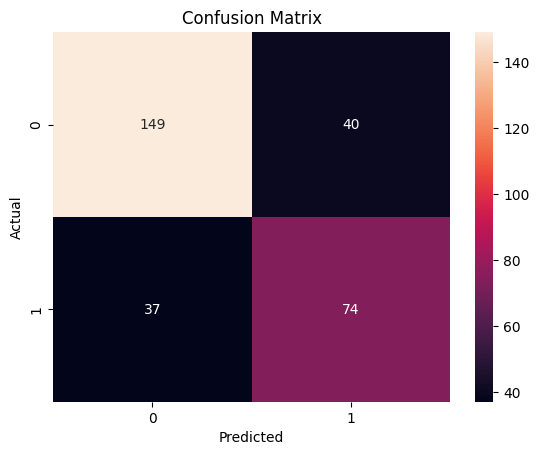

ROC-AUC: 0.7927927927927928


In [23]:
from src.preprocessing import preprocess_pipeline
from src.evaluate import (
    evaluate_all,
    plot_confusion,
    roc_score
)

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# preprocess data
X_train, X_test, y_train, y_test = preprocess_pipeline(
    "../data/raw/lung_cancer.csv"
)

# train model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
xgb_model.fit(X_train, y_train)

# store models
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
}

# evaluate all
evaluate_all(models, X_test, y_test)

# predictions for one model
y_pred = log_model.predict(X_test)

# confusion matrix
plot_confusion(y_test, y_pred)

# roc auc
roc_score(log_model, X_test, y_test)

Model Explaination